In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('kc_house_data.csv')
data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
len(data)

21613

In [4]:
data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21611.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.396095,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.128162,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


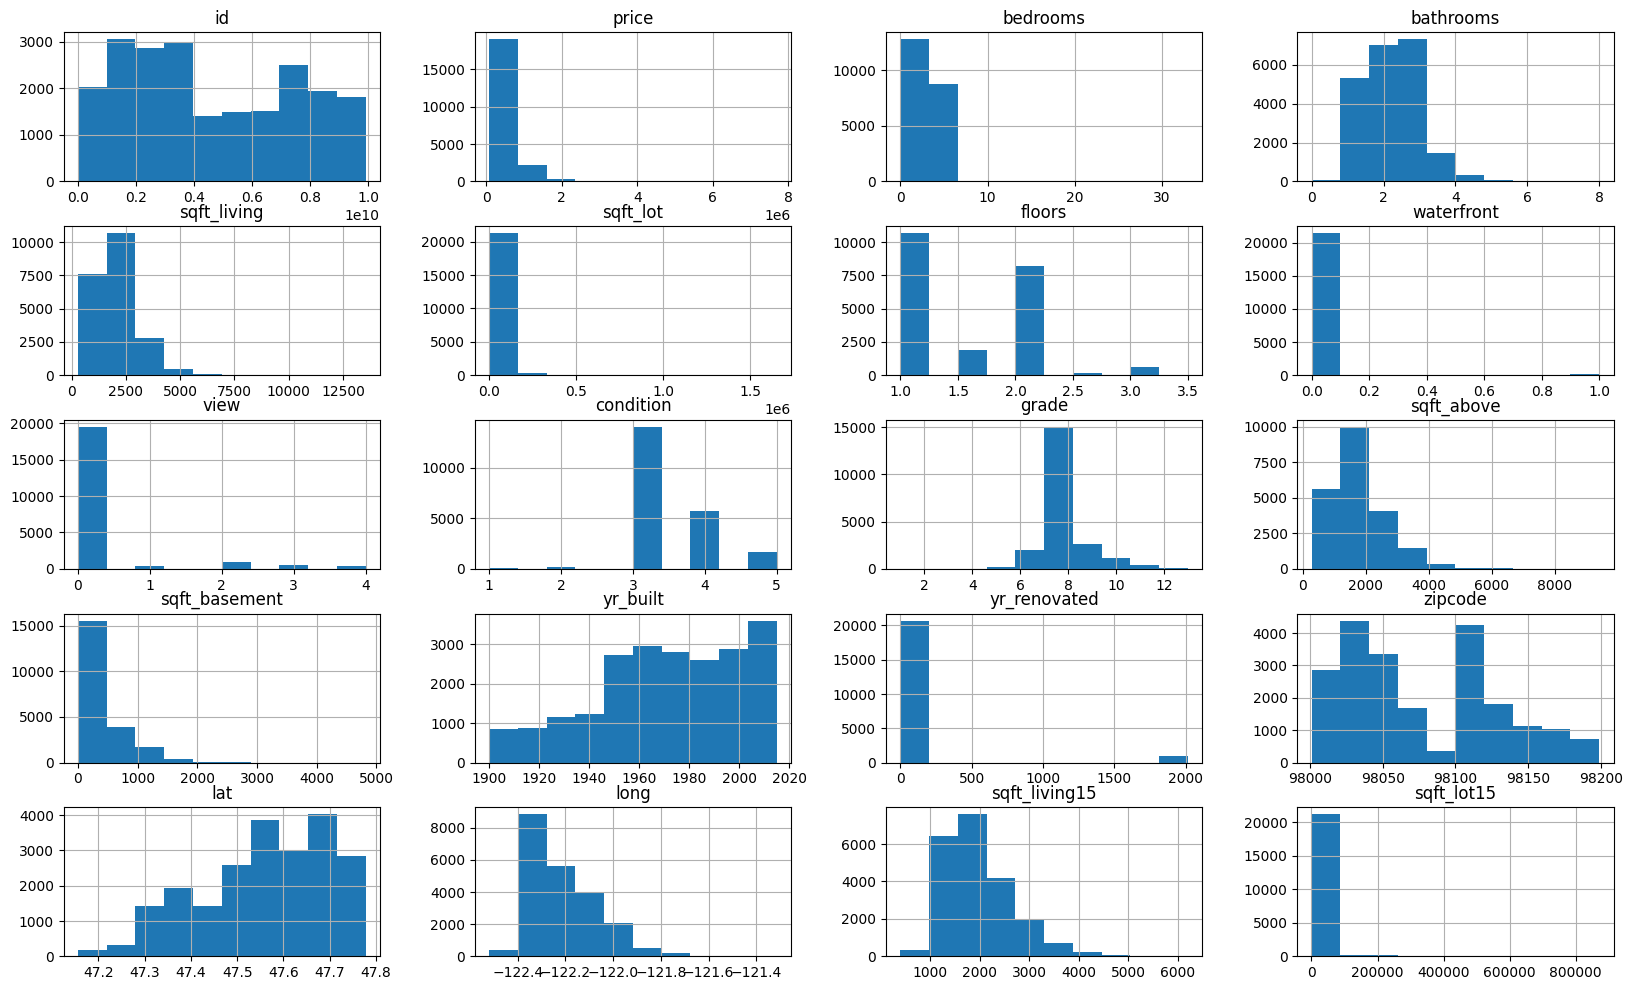

In [5]:
data.hist(figsize=(20, 12));

In [6]:
import xgboost as xgb
import numpy as np

In [7]:
X = data.iloc[:,3:].values
y = data['price'].values

In [8]:
np.shape(y)

(21613,)

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [10]:
xg_reg = xgb.XGBRegressor(colsample_bytree=0.8, learning_rate=0.1, max_depth=6, n_estimatrs =1000, verbosity=3)

In [11]:
xg_reg.fit(X_train, y_train)

[23:15:13] ======== Monitor (0): HostSketchContainer ========
[23:15:13] AllReduce: 0.014139s, 1 calls @ 14139us

[23:15:13] MakeCuts: 0.014284s, 1 calls @ 14284us

[23:15:13] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (16209, 18, 291760).
[23:15:13] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:127: Using tree method: 0


c:\Users\amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:15:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "n_estimatrs" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[23:15:14] ======== Monitor (0): GBTree ========
[23:15:14] BoostNewTrees: 0.708032s, 100 calls @ 708032us

[23:15:14] CommitModel: 0.000107s, 100 calls @ 107us

[23:15:14] ======== Monitor (0): HistUpdater ========
[23:15:14] BuildHistogram: 0.160218s, 500 calls @ 160218us

[23:15:14] EvaluateSplits: 0.322316s, 600 calls @ 322316us

[23:15:14] InitData: 0.003971s, 100 calls @ 3971us

[23:15:14] InitRoot: 0.123906s, 100 calls @ 123906us

[23:15:14] LeafPartition: 2.3e-05s, 100 calls @ 23us

[23:15:14] UpdatePosition: 0.104435s, 600 calls @ 104435us

[23:15:14] UpdatePredictionCache: 0.019463s, 100 calls @ 19463us

[23:15:14] UpdateTree: 0.68684s, 100 calls @ 686840us

[23:15:14] ======== Monitor (0):  ========
[23:15:14] BuildHist: 0.179298s, 600 calls @ 179298us



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_estimatrs=1000, n_jobs=None, ...)

In [12]:
y_pred = xg_reg.predict(X_test)

[23:15:14] DEBUG: C:\actions-runner\_work\xgboost\xgboost\src\gbm\gbtree.cc:127: Using tree method: 0


In [13]:
from sklearn import metrics

In [14]:
metrics.mean_absolute_error(y_test, y_pred)

65537.79185556994

In [15]:
metrics.r2_score(y_test, y_pred)

0.8906669524647527

In [16]:
data['price'].mean()

np.float64(540088.1417665294)

In [17]:
data['price'].std()

np.float64(367127.19648269983)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

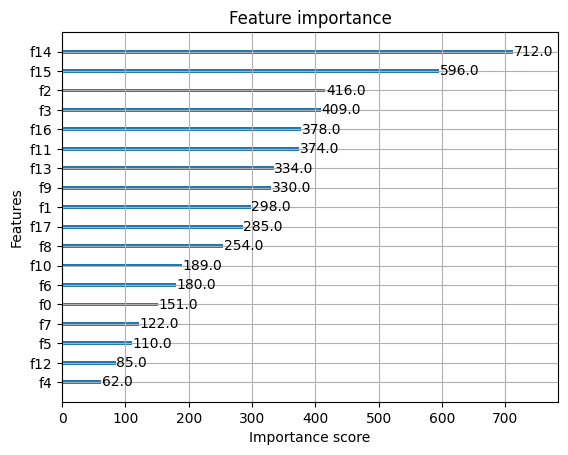

In [18]:
xgb.plot_importance(xg_reg)